In [1]:
## Data Cleaning

In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [134]:
## Load the data

In [135]:
df = sns.load_dataset("titanic")

In [136]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [137]:
df.shape

(891, 15)

In [138]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [140]:
df.describe(include = "object")

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [141]:
#Missing values

In [142]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [143]:
missing_percent = (df.isnull().sum()/(len(df)))

In [144]:
missing_percent

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

<Axes: >

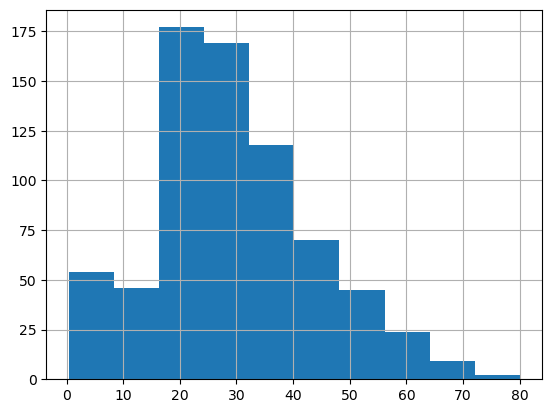

In [145]:
df["age"].hist()

In [146]:
df["age"] = df["age"].fillna(df["age"].median())

In [147]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode())

In [148]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [149]:
df["embarked"].mode()[0]

'S'

In [150]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [151]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

In [152]:
df.drop(columns = ["deck"], inplace = True)

In [153]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [154]:
# Duplicate data

In [155]:
df.duplicated().sum()

116

In [156]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [157]:
df = df.drop_duplicates()

In [158]:
df.duplicated().sum()

0

In [159]:
# Data type Cleaning

In [160]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [161]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

In [177]:
# boolean to int

# df["adult_male"] = df["adult_male"].astype(int)
df.loc[:, "adult_male"] = df["adult_male"].astype(int)

In [176]:
df.loc[:,"alone"] = df["alone"].astype(int)

In [164]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [165]:
df.loc[:,"sex"] = df["sex"].str.lower()

In [166]:
df.loc[:,"embark_town"] = df["embark_town"].str.strip()

In [167]:
## Outliers

<Axes: ylabel='fare'>

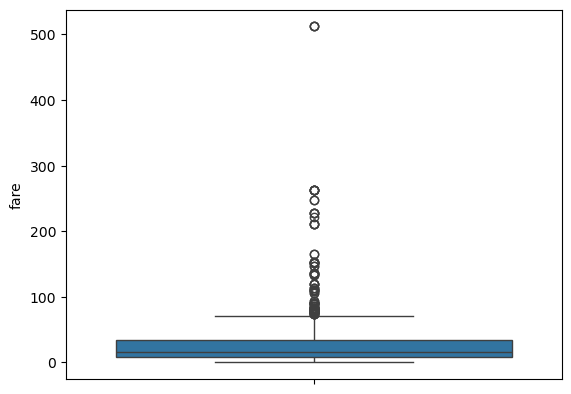

In [168]:
sns.boxplot(df["fare"])

In [178]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [179]:
## identify the outliers

In [180]:
outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]

In [181]:
outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0,Cherbourg,yes,0
54,0,1,male,65.0,0,1,61.9792,C,First,man,1,Cherbourg,no,0
74,1,3,male,32.0,0,0,56.4958,S,Third,man,1,Southampton,yes,1
92,0,1,male,46.0,1,0,61.1750,S,First,man,1,Southampton,no,0
97,1,1,male,23.0,0,1,63.3583,C,First,man,1,Cherbourg,yes,0
151,1,1,female,22.0,1,0,66.6000,S,First,woman,0,Southampton,yes,0
155,0,1,male,51.0,0,1,61.3792,C,First,man,1,Cherbourg,no,0
159,0,3,male,28.0,8,2,69.5500,S,Third,man,1,Southampton,no,0
166,1,1,female,28.0,0,1,55.0000,S,First,woman,0,Southampton,yes,0
169,0,3,male,28.0,0,0,56.4958,S,Third,man,1,Southampton,no,1


In [182]:
## remove Outliers

In [183]:
df = df[(df["fare"] >= lower) & (df["fare"] <= upper)]

<Axes: ylabel='fare'>

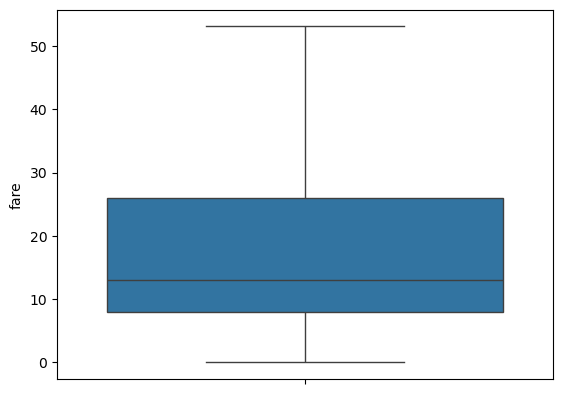

In [184]:
sns.boxplot(df["fare"])

In [185]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1,Southampton,no,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0,Southampton,yes,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0,Southampton,yes,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1,Southampton,no,1
5,0,3,male,28.0,0,0,8.4583,Q,Third,man,1,Queenstown,no,1


In [186]:
df["survived"].value_counts()

survived
0    418
1    225
Name: count, dtype: int64

In [187]:
df["pclass"].value_counts()

pclass
3    395
2    157
1     91
Name: count, dtype: int64

In [189]:
df.isnull().sum()
df.dtypes
df.shape
df.describe()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
count,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000,643.000000
mean,0.349922,2.472784,28.666407,0.486781,0.387247,17.545334,0.608087,0.620529
std,0.477316,0.730162,13.542451,0.952646,0.839611,11.941606,0.488557,0.485633
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000,1.000000,1.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000,26.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,5.000000,6.000000,53.100000,1.000000,1.000000


In [190]:
# save dara to new files

In [192]:
df.to_csv("titanic_data_cleaned.csv", index = False)

In [193]:
## resulable data quality report functions

In [199]:
def data_quality_report(df):
    report = {
        "shape" : df.shape,
        "missing_values" : df.isnull().sum(),
        "duplicate_count" : int(df.duplicate().sum()),
        "data_types" : df.types.astype(str).to_dict()
    }
    return report
